# imports

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
from jaxtyping import Float
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg, dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import (
	null_stats,
	filter_data,
	normalize_data,
	pca_importance_table,
	aggregate_feature_stats,
	plot_importance_covariance,
)
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

In [4]:
# raw data from file instead of regenerating
# DATA_RAW = pl.read_ndjson(PATH_BASE / "raw.jsonl")
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw-m8-p128-c101.jsonl")

# basic data inspection

In [5]:
# display(DATA_RAW)
# display(set(DATA_RAW.dtypes))
# display(DATA_RAW.head())
# display(DATA_RAW.describe())
# print(f"{DATA_RAW['activation.model'].unique() = }")
# for col in DATA_RAW.columns:
# 	if col.startswith("activation"):
# 		print(f"{col = }")
display(null_stats(DATA_RAW))

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
…,…,…
"""activation.layer""",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.diag.linreg.r2""",0,0.0


# filter nans and certain models

In [6]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/214016 rows
Removing 2/94 feat.* columns due to zero variance or excessive missing values
feat.log.gram.row.beta_hist.hist.raw.median                  μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=194560 dtype=float64
feat.log.gram.col.beta_hist.hist.raw.median                  μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=194560 dtype=float64


feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
…,…,…
"""activation.layer""",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.diag.linreg.r2""",0,0.0


# scaling

In [7]:
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
DATA_SCALED: pl.DataFrame
DATA_NORMS: pl.DataFrame
DATA_SCALED, DATA_NORMS = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_NORMS.write_ndjson(PATH_BASE / "scaling.jsonl")
# display(DATA_SCALED)
display(null_stats(DATA_SCALED))
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
…,…,…
"""activation.layer""",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.diag.linreg.r2""",0,0.0


In [8]:
# plot_correlation_matrix(
# 	DATA_SCALED,
# 	FEATURE_COLS,
# 	sort_by="var",
# )

In [9]:
# TEMP: drop specific columns

# DATA_SCALED_DROPPED: pl.DataFrame = DATA_SCALED.drop(
# 	x
# 	for x in
# 	DATA_SCALED.columns
# 	if x.startswith("feat.") and (
# 		x.endswith("rms") or
# 		x.endswith("L1_norm") or (
# 			x.startswith("feat.markov_transition.diff")
# 			and not (
# 				x.endswith("kurtosis")
# 				or x.endswith("skewness")
# 			)
# 		)
# 		# remove energy except for first_tok and diag
# 		or (
# 			(
# 				x.endswith(".energy")
# 				or x.endswith(".kurtosis")
# 				or x.endswith(".L2_norm")
# 			)
# 			and not (
# 				x.startswith("feat.first_tok")
# 				or x.startswith("feat.diag")
# 				or x.startswith("feat.markov_transition.diff")
# 			)
# 		)
# 	)
# )
# print(f"{DATA_SCALED.shape = }")
# print(f"{DATA_SCALED_DROPPED.shape = }")
# DATA_SCALED = DATA_SCALED_DROPPED
# FEATURE_COLS: list[str] = [
# 	col for col in DATA_SCALED.columns if col.startswith("feat.")
# ]

# PCA

[ <ipykernel>:2 ] DATA_SCALED[FEATURE_COLS].to_numpy(): μ=0.00 σ=1.00 x̃=-0.16 R=[-16.31,31.13] ℙ=|  █    | shape=(194560,92) dtype=float64


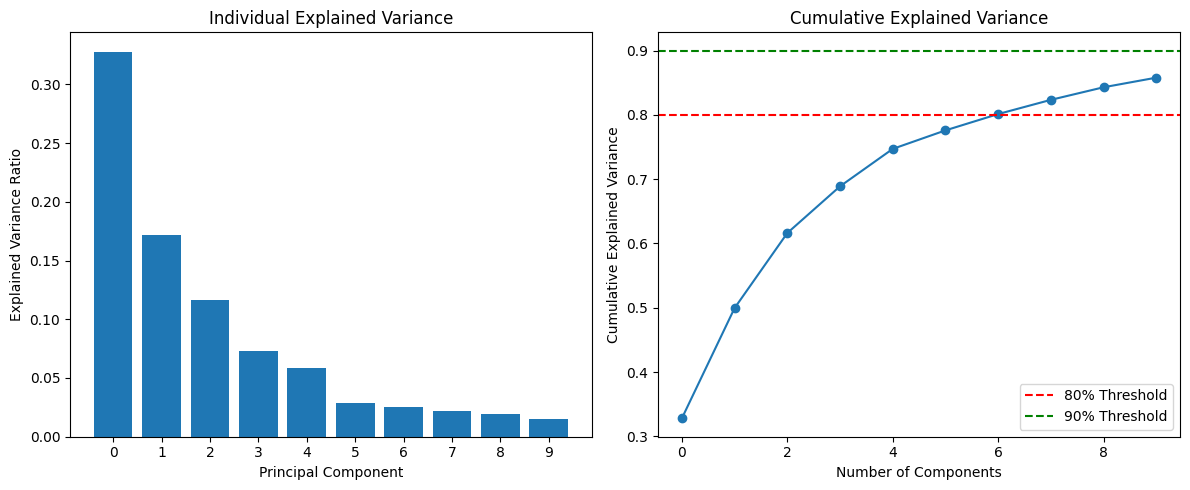

Number of components: 10
Total explained variance: 0.8581
Components needed for 80% variance: 7
Components needed for 90% variance: 1


[ <ipykernel>:7 ] PCA_DATA: μ=0.00 σ=2.81 x̃=-0.14 R=[-13.83,28.78] ℙ=| ▂█    | shape=(194560,10) dtype=float64
[ <ipykernel>:16 ] len(FEATURE_COLS) = 92
[ <ipykernel>:17 ] PCA_OBJ.components_: μ=0.00 σ=0.10 x̃=-0.00 R=[-0.32,0.40] ℙ=| ▂▇█▂  | shape=(10,92) dtype=float64


In [10]:
# PCA
dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
PCA_DATA: np.ndarray
PCA_OBJ: PCA
PCA_DATA, PCA_OBJ = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)
# save pca data
dbg_tensor(PCA_DATA)
np.save(PATH_BASE / "pca.npy", PCA_DATA)

# only columns that start with "activation."
# for labelling the PCA plot in the webapp
data_meta: pl.DataFrame = DATA_SCALED[
	[col for col in DATA_SCALED.columns if col.startswith("activation.")]
]
data_meta.write_ndjson(PATH_BASE / "meta.jsonl")
dbg(len(FEATURE_COLS))
dbg_tensor(PCA_OBJ.components_)

# pca and meta in one dataframe
pca_cols: list[str] = [f"pc.{i}" for i in range(PCA_DATA.shape[1])]
DF_PCA: pl.DataFrame = pl.DataFrame(PCA_DATA, schema=pca_cols)
DF_PCA = pl.concat([DF_PCA, data_meta], how="horizontal")
DF_PCA.write_ndjson(PATH_BASE / "pca.jsonl")

In [11]:
df_importance: pl.DataFrame = pca_importance_table(
	PCA_OBJ,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.beta_hist.hi…",0.175145,-0.028945,-0.010196,0.033493,-0.032688,-0.013156,0.032888,0.02886,0.034006,-0.016511,0.040589,0.175145,0.002085,0.070694
"""feat.log.gram.col.beta_hist.hi…",-0.173638,0.037772,-0.011184,-0.033725,0.045994,0.001506,-0.05119,-0.033105,-0.011323,0.029667,0.04291,0.173638,0.002127,0.072598
"""feat.log.gram.col.beta_hist.hi…",-0.171375,0.039043,0.039099,-0.015268,0.015728,0.003857,0.008708,-0.042172,-0.054364,0.021774,0.041139,0.171375,0.002128,0.072141
"""feat.log.gram.col.beta_hist.hi…",0.170928,-0.04129,0.024326,0.031691,-0.05355,0.00693,0.058974,0.032195,0.00996,-0.033297,0.046314,0.170928,0.001971,0.074502
"""feat.log.gram.col.beta_hist.hi…",-0.170316,0.042038,0.042,-0.011483,0.0132,0.000083,0.014496,-0.045648,-0.056277,0.023803,0.041934,0.170316,0.002129,0.072407
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat.first_tok.entropy""",-0.004029,-0.158586,-0.013536,-0.05378,0.261133,0.056702,0.043948,-0.071943,0.00566,0.054096,0.072341,0.261133,0.005738,0.054495
"""feat.gram.row.beta_hist.hist.r…",-0.002972,0.199096,-0.04057,0.024529,-0.154572,0.247228,-0.080188,-0.012783,-0.023325,-0.05814,0.08434,0.247228,0.006629,0.061429
"""feat.first_tok.kurtosis""",-0.00257,0.159032,-0.017511,-0.024788,-0.216914,-0.037234,0.029716,0.029418,0.117138,-0.108424,0.074275,0.216914,0.004672,0.051006


In [12]:
display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""log""",0.065912,0.040589,0.127447,0.061847
"""diag""",0.098162,0.086339,0.122407,0.095952
"""first_tok""",0.085224,0.065009,0.117652,0.079818
"""gram""",0.079867,0.042467,0.11373,0.082139


/home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


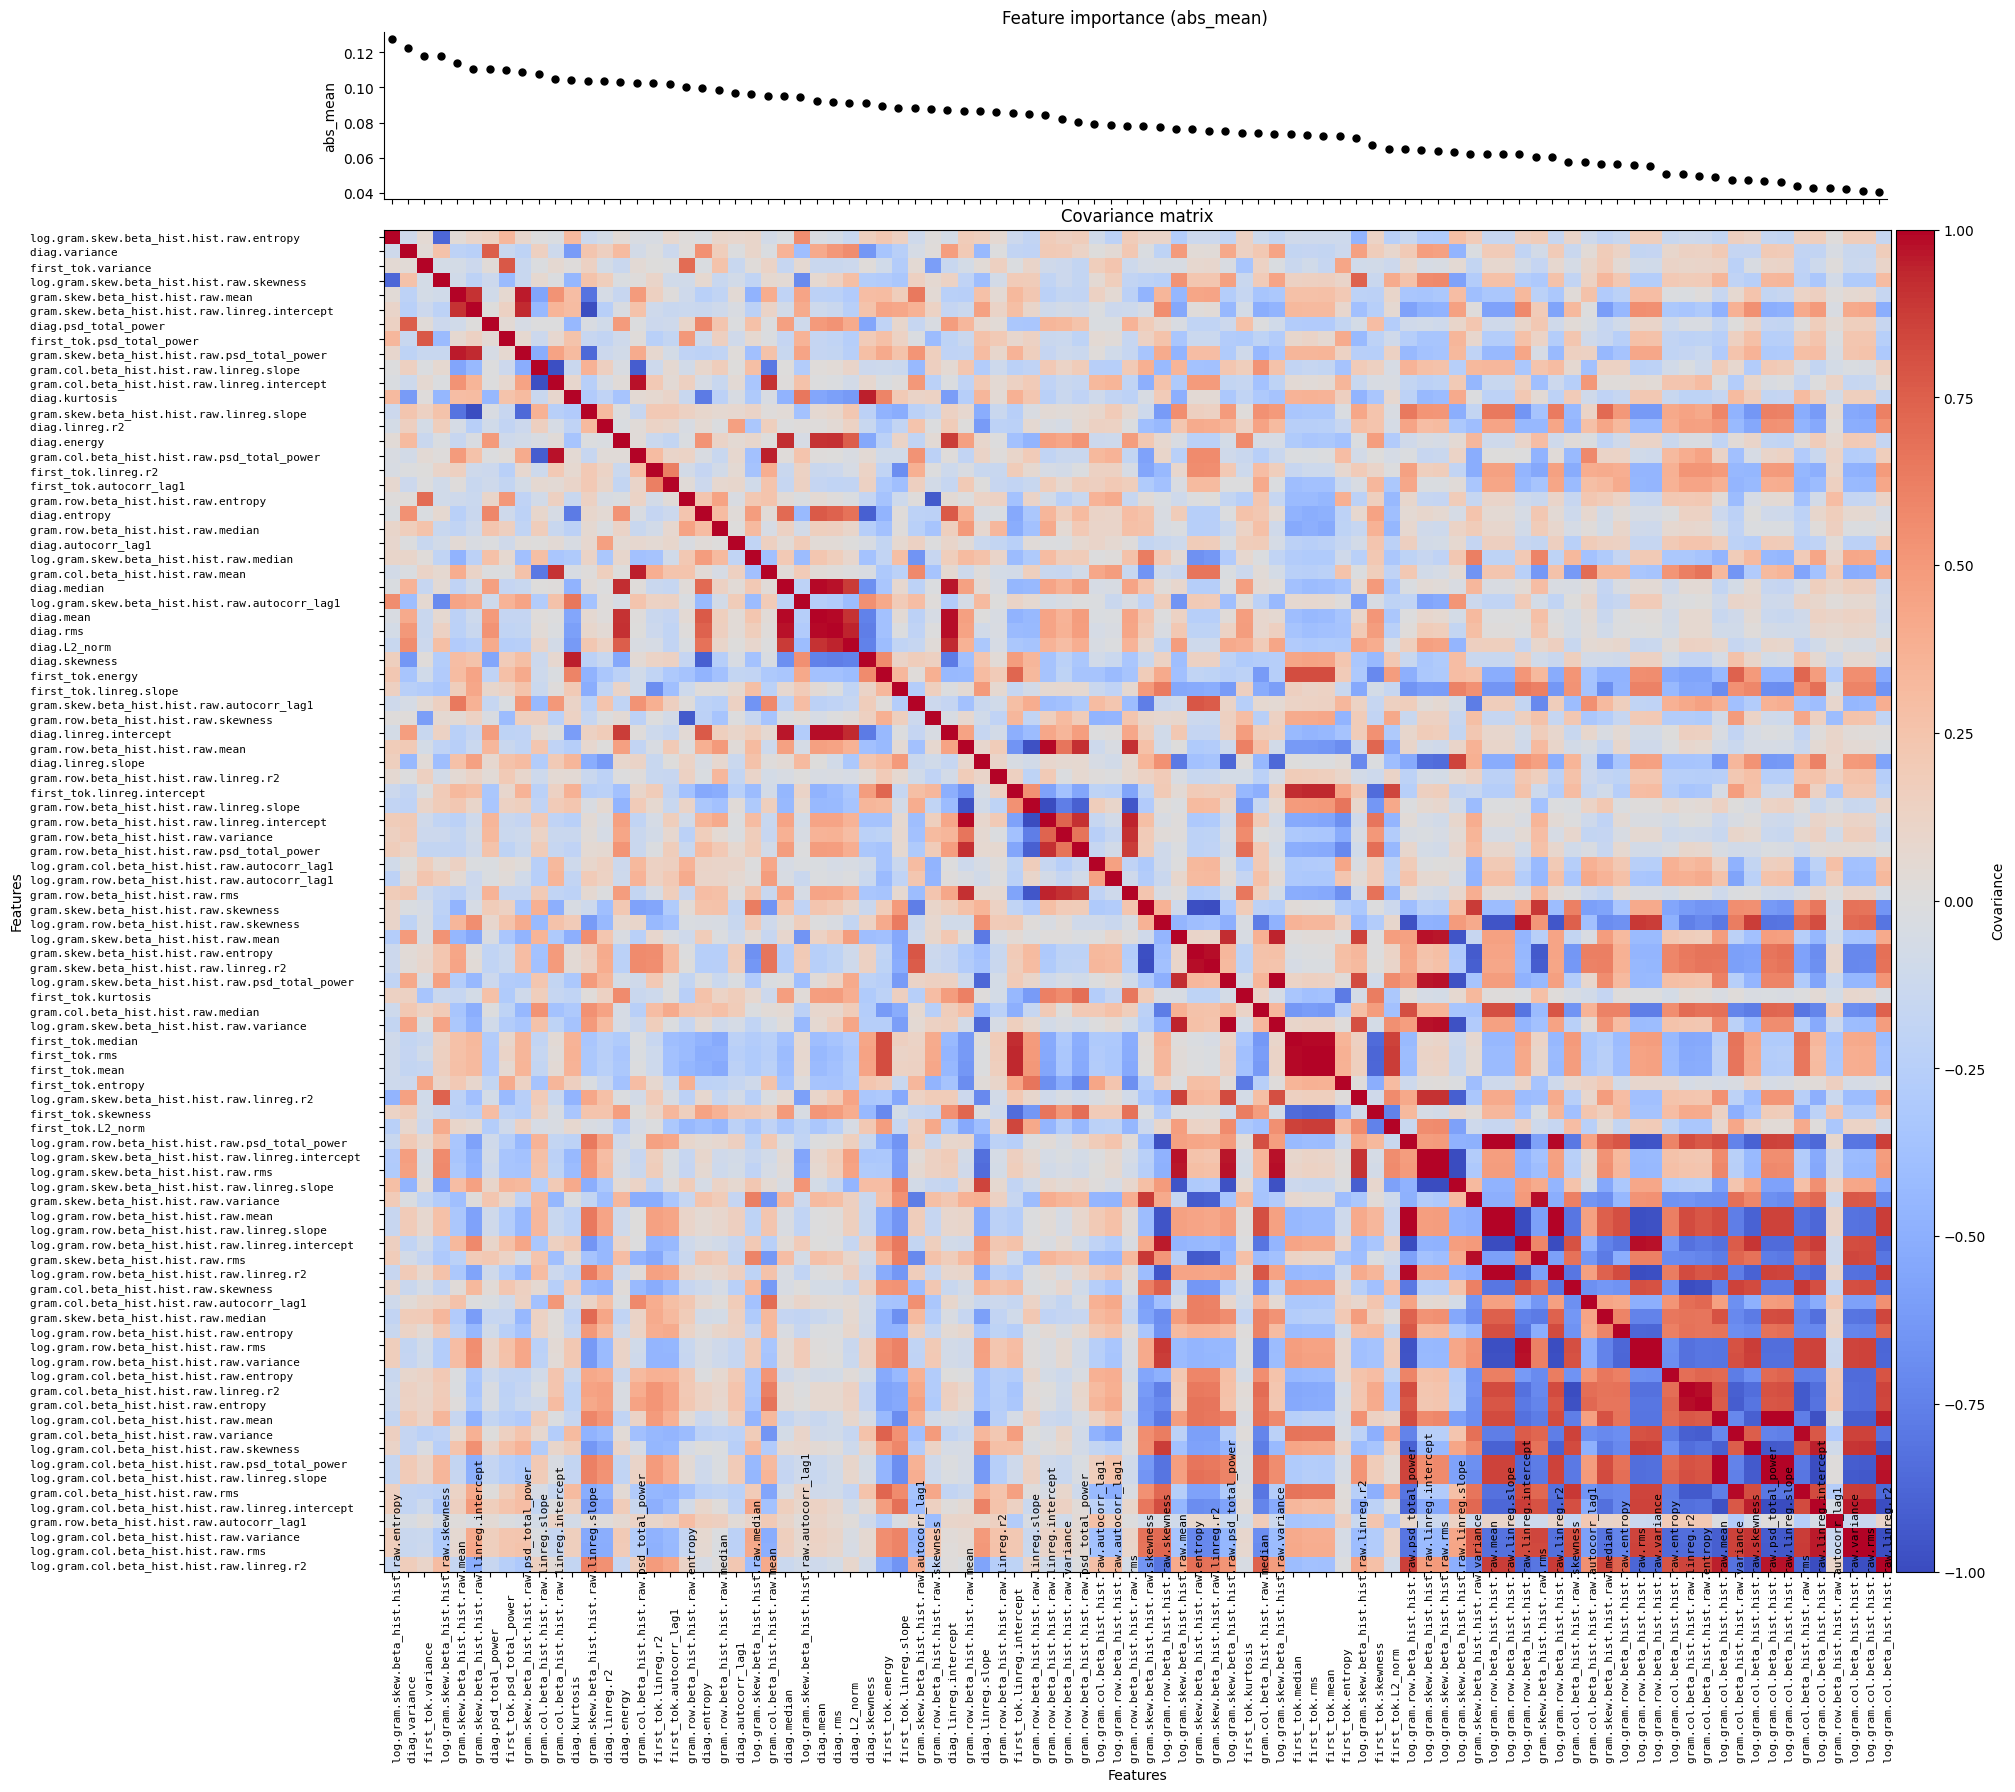

In [13]:
cov_feats, cov_mat = plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metric="abs_mean",
	descending=True,
	cmap="coolwarm",
	figsize=(20, 20),
)

In [14]:
def groups_by_covariance(
	features: list[str],
	cov: Float[np.ndarray, "n n"],
	threshold: float,
	use_abs: bool = True,
) -> list[list[str]]:
	n: int = len(features)
	assert n == cov.shape[0] == cov.shape[1], (
		"Covariance matrix must be square and match the number of features."
	)

	# |cov| if desired, then a boolean matrix marking edges above threshold
	comparison_matrix: Float[np.ndarray, "n n"] = np.abs(cov) if use_abs else cov
	adjacency_matrix: Float[np.ndarray, "n n"] = comparison_matrix > threshold

	visited_indices: set[int] = set()
	groups: list[list[str]] = []

	# Depth-first search over the implicit graph
	for start_idx in range(n):
		if start_idx in visited_indices:
			continue
		stack: list[int] = [start_idx]
		component_indices: list[int] = []

		while stack:
			idx: int = stack.pop()
			if idx in visited_indices:
				continue
			visited_indices.add(idx)
			component_indices.append(idx)

			# All indices j where adjacency_matrix[idx, j] is True
			neighbors: np.ndarray = np.where(adjacency_matrix[idx])[0]
			stack.extend([j for j in neighbors if j not in visited_indices])

		groups.append([features[j] for j in component_indices])

	return groups


groups: list[list[str]] = groups_by_covariance(cov_feats, cov_mat, threshold=0.95)
singletons: list[list[str]] = [g for g in groups if len(g) == 1]
# print(f"{singletons = }")
# print singleton features with their importance
# get the row from df_importance that matches the feature name
singleton_info = [
	(g[0], df_importance.filter(pl.col("feature").is_in(g)).to_dicts()[0]["abs_max"])
	for g in singletons
]
for feat, imp in sorted(singleton_info, key=lambda x: x[1], reverse=True):
	print(f"{feat:60} {imp:.3f}")

for g in groups:
	if len(g) == 1:
		continue
	print(g)

feat.diag.psd_total_power                                    0.404
feat.log.gram.skew.beta_hist.hist.raw.entropy                0.376
feat.diag.variance                                           0.340
feat.first_tok.psd_total_power                               0.340
feat.gram.row.beta_hist.hist.raw.entropy                     0.324
feat.diag.linreg.r2                                          0.323
feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1          0.322
feat.gram.row.beta_hist.hist.raw.skewness                    0.319
feat.log.gram.skew.beta_hist.hist.raw.skewness               0.318
feat.gram.row.beta_hist.hist.raw.linreg.r2                   0.316
feat.first_tok.variance                                      0.277
feat.first_tok.entropy                                       0.261
feat.diag.autocorr_lag1                                      0.260
feat.log.gram.skew.beta_hist.hist.raw.median                 0.248
feat.first_tok.L2_norm                                       0

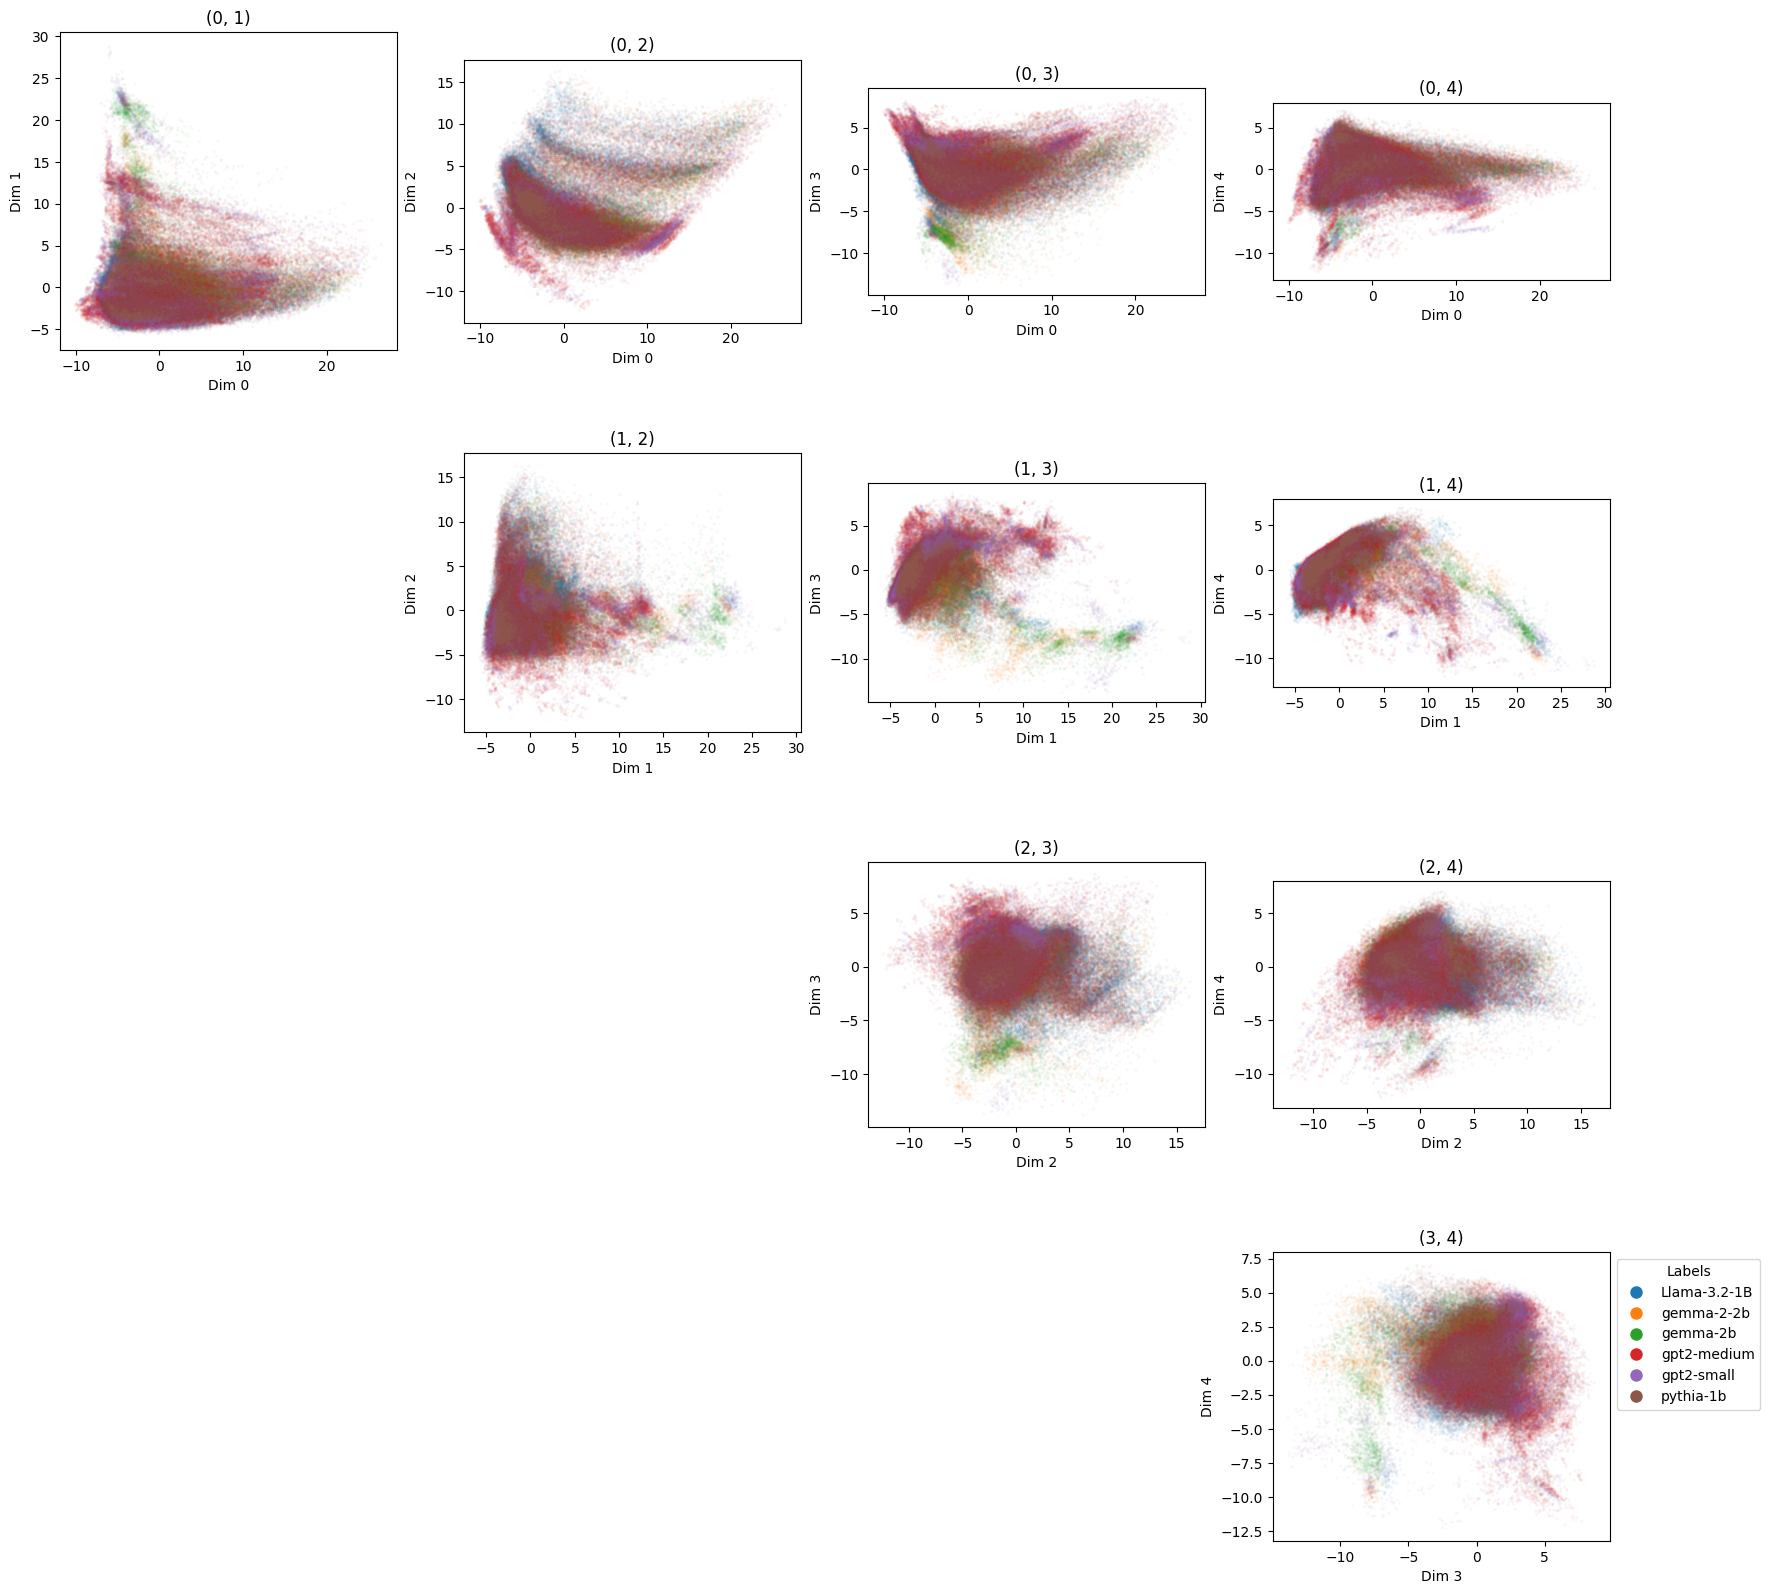

In [15]:
n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims - 1,
	n_dims - 1,
	figsize=(20, 20),
)
for i in range(0, n_dims - 1):
	for j in range(i + 1, n_dims):
		plot_embedding(
			PCA_DATA,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=5,
			title=f"({i}, {j})",
			ax=embed_ax[i, j - 1],
		)
	for k in range(0, i):
		embed_ax[i, k].axis("off")

In [16]:
DATA_SCALED

feat.log.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.log.gram.col.beta_hist.hist.raw.variance,feat.first_tok.variance,feat.first_tok.kurtosis,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.col.beta_hist.hist.raw.skewness,activation.model,activation.cls,feat.first_tok.autocorr_lag1,feat.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.mean,feat.first_tok.L2_norm,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.diag.L2_norm,feat.first_tok.linreg.slope,feat.gram.skew.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.linreg.r2,feat.gram.col.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.variance,feat.diag.mean,feat.first_tok.median,feat.first_tok.linreg.intercept,feat.diag.skewness,feat.diag.autocorr_lag1,feat.diag.linreg.slope,feat.gram.row.beta_hist.hist.raw.variance,activation.n_ctx,…,feat.first_tok.energy,activation.cache_key,feat.diag.rms,feat.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,activation.head,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.entropy,feat.log.gram.col.beta_hist.hist.raw.entropy,feat.log.gram.skew.beta_hist.hist.raw.variance,feat.gram.skew.beta_hist.hist.raw.entropy,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.rms,feat.first_tok.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.diag.energy,feat.first_tok.skewness,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.gram.row.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.linreg.slope,feat.gram.col.beta_hist.hist.raw.median,feat.log.gram.row.beta_hist.hist.raw.linreg.r2,feat.diag.entropy,feat.gram.skew.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.entropy,activation.layer,feat.log.gram.col.beta_hist.hist.raw.mean,feat.diag.linreg.r2,feat.first_tok.psd_total_power,feat.first_tok.mean
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,…,f64,str,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64
-1.950965,-0.202521,0.763975,-0.365125,-0.043862,0.932892,1.049703,-0.355537,-0.27878,4.781122,-1.349667,0.735821,"""gemma-2b""","""gemma-2b:L0:H0""",-1.787147,-0.284212,-0.683861,-0.06103,-0.730617,0.286587,0.215031,-0.694588,1.08439,-0.63981,-1.078767,-0.622777,-0.819866,-0.766695,0.9532,0.188895,0.271778,0.030602,-1.25653,-0.52873,0.551493,-0.166883,109,…,-0.004741,"""blocks.0.attn.hook_pattern""",0.458822,-0.743633,0.632443,-0.417044,0,0.255678,0.95897,-0.684034,1.588887,-0.91877,-0.336878,-1.104428,-0.724955,0.45062,0.787336,-0.692938,-0.649108,0.090481,-0.527129,0.091779,-0.590856,-0.467188,-0.218839,0.155049,-0.504639,-0.690024,0.924762,1.106297,-1.545033,-0.278865,0,-0.760119,-1.059392,0.745983,0.0534
-1.950965,-0.273348,0.932186,-0.863056,-0.193015,1.017918,3.126453,-0.441883,-0.481843,-0.648657,-0.342122,0.820295,"""gemma-2b""","""gemma-2b:L0:H1""",-2.060197,-0.165753,-0.683861,-0.054721,-0.896396,-0.456135,0.930868,-1.063533,2.224222,-1.19